Goal: ensure CNN can perform better than random actions in test matches.

In [15]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add modeling/ to path so experiment.py and networks.py are importable
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from experiment import REGISTRY, build_model
from reward import compute_rewards_for_episode, RewardWeights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

In [16]:
# ── Select experiment ────────────────────────────────────────────────────────
# Change this one string to switch experiments. Everything else is derived.
cfg = REGISTRY["deep_q_v1.1"]

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = PROJECT_ROOT / "data" / "test_won_in_area2"
TRAINING_CSV = DATA_DIR / "training_data.csv"
SCREENS_DIR = Path("../input_capture/re_resistance_captures/won_in_area2/screens")

# ── Derived from config ───────────────────────────────────────────────────────
IMG_SIZE              = cfg.img_size
STACK_SIZE            = cfg.stack_size
BATCH_SIZE            = cfg.batch_size
LEARNING_RATE         = cfg.learning_rate
GAMMA                 = cfg.gamma
NUM_EPOCHS            = cfg.num_epochs
MAX_EARLY_STOP_EPOCHS = cfg.max_early_stop_epochs
L1_INACTIVE_WEIGHT    = cfg.l1_inactive_weight
TRAIN_SPLIT           = cfg.train_split
STARTING_FRAME        = cfg.starting_frame
OUTPUT_COLUMNS        = list(cfg.output_columns)
NUM_OUTPUTS           = cfg.num_outputs
MOUSE_COLUMNS         = ["mouse_x", "mouse_y", "mouse_dx", "mouse_dy"]
KEY_COLUMNS           = [c for c in OUTPUT_COLUMNS if c not in MOUSE_COLUMNS]

print(f"Experiment:         {cfg.name}")
print(f"Network:            {cfg.network_class}")
print(f"Binary keys:        {len(KEY_COLUMNS)}")
print(f"Mouse axes:         {len(MOUSE_COLUMNS)}")
print(f"Total output heads: {NUM_OUTPUTS}")
print(f"CNN input shape:    ({STACK_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]})")
print(f"Inactive-head L1 weight: {L1_INACTIVE_WEIGHT}")
print(f"Training CSV: {TRAINING_CSV}")

Experiment:         deep_q_v1.1
Network:            DQN_V1.1
Binary keys:        22
Mouse axes:         4
Total output heads: 26
CNN input shape:    (20, 224, 224)
Inactive-head L1 weight: 0.05
Training CSV: C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\data\test_won_in_area2\training_data.csv


## 2. Load data & compute rewards

In [17]:
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df)} frames, columns: {list(df.columns)}")

# Compute per-frame rewards using the naive equal-weight reward function
rows = df.to_dict(orient="records")
rewards = compute_rewards_for_episode(rows, apply_relu=True) # deepq1_v1.1: apply ReLU to time burn and related time rewards
df["reward"] = rewards

# Preprocessing: filter out all rewards/punishments larger than 100
# Highly unlikely this actually happens in a game. Usually a product of poor extraction.
df.loc[df['reward'].abs() >= 100, 'reward'] = 0

# Preprocessing: skip frames before the game actually starts (loading + white flash)
df = df[df['frame'] >= STARTING_FRAME]

# Normalize rewards to zero mean, unit variance
reward_mean = df["reward"].mean()
reward_std = df["reward"].std()
df["reward"] = (df["reward"] - reward_mean) / (reward_std + 1e-8)
print(f"\nReward normalized: mean={reward_mean:.4f}, std={reward_std:.4f}")

# Compute discounted return (target for Q-learning)
returns = np.zeros(len(df))
running = 0.0
for t in reversed(range(len(df))):
    running = df["reward"].iloc[t] + GAMMA * running
    returns[t] = running
df["discounted_return"] = returns

print(f"\nReward stats (normalized):")
print(df["reward"].describe())
print(f"\nDiscounted return stats:")
print(df["discounted_return"].describe())

Loaded 9952 frames, columns: ['frame', 'timestamp', 'mouse_x', 'mouse_y', 'mouse_left', 'mouse_middle', 'mouse_right', 'mouse_dx', 'mouse_dy', 'key_w', 'key_a', 'key_s', 'key_d', 'key_q', 'key_e', 'key_r', 'key_f', 'key_v', 'key_m', 'key_1', 'key_2', 'key_3', 'key_4', 'key_space', 'key_up', 'key_down', 'key_left', 'key_right', 'time_burn_delta', 'bio_energy', 's1_health', 's1_infection', 's2_health', 's2_infection', 's3_health', 's3_infection', 's4_health', 's4_infection', 'camera_status']

Reward normalized: mean=1.4870, std=3.0258

Reward stats (normalized):
count    9.561000e+03
mean     4.459007e-17
std      1.000000e+00
min     -4.914219e-01
25%     -4.914219e-01
50%     -1.609341e-01
75%      1.695536e-01
max      2.904427e+01
Name: reward, dtype: float64

Discounted return stats:
count    9561.000000
mean        0.165690
std        35.962067
min       -45.913490
25%       -26.741608
50%        -7.561124
75%        14.838010
max       125.356092
Name: discounted_return, dtype: fl

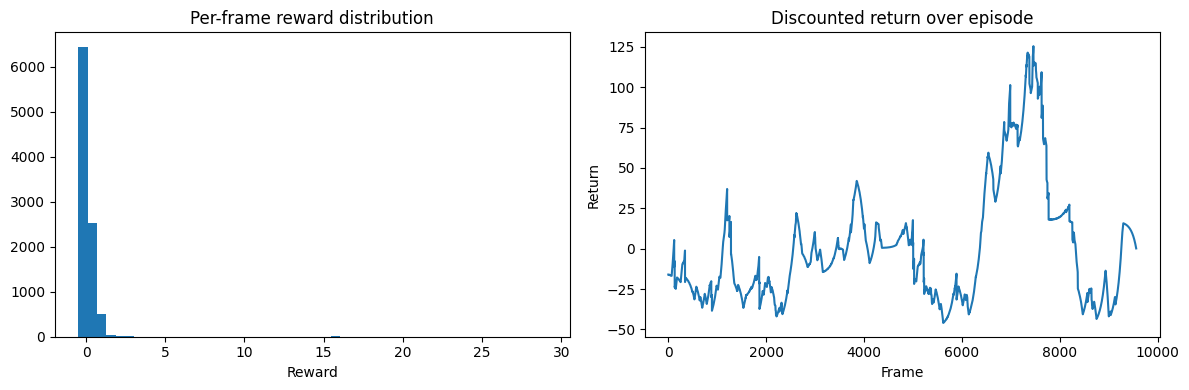

In [18]:
# Quick reward distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["reward"], bins=50)
axes[0].set_title("Per-frame reward distribution")
axes[0].set_xlabel("Reward")
axes[1].plot(df["discounted_return"].values)
axes[1].set_title("Discounted return over episode")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Return")
plt.tight_layout()
plt.show()

## 3. Dataset

In [19]:
class ResistanceDataset(Dataset):
    """Dataset over non-overlapping stacks of STACK_SIZE consecutive frames.

    Each item corresponds to one stack:
    - `sample_starts` is a list of row indices into `dataframe`, one per stack.
    - frames [start, start+1, ..., start+S-1] are stacked → (STACK_SIZE, H, W)
    - actions and Q-target come from the LAST frame in each stack.

    Decoupling sample selection from the dataframe lets train/val splits be
    spread across the full episode rather than split temporally.
    """

    def __init__(self, dataframe: pd.DataFrame, screens_dir: Path,
                 sample_starts: list, transform=None, stack_size: int = 4):
        self.df = dataframe
        self.screens_dir = screens_dir
        self.sample_starts = sample_starts
        self.transform = transform
        self.stack_size = stack_size

    def __len__(self):
        return len(self.sample_starts)

    def _load_frame(self, frame_num: int) -> torch.Tensor:
        img_path = self.screens_dir / f"frame_{frame_num:06d}.jpg"
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

    def __getitem__(self, idx):
        start = self.sample_starts[idx]
        frames = [
            self._load_frame(int(self.df.iloc[start + k]["frame"]))
            for k in range(self.stack_size)
        ]
        stacked = torch.cat(frames, dim=0)  # (STACK_SIZE, H, W)

        # Actions and target come from the last (current) frame of the stack
        row = self.df.iloc[start + self.stack_size - 1]
        actions = torch.tensor([row[c] for c in OUTPUT_COLUMNS], dtype=torch.float32)
        target  = torch.tensor(row["discounted_return"], dtype=torch.float32)

        return stacked, actions, target

In [20]:
# DeepMind-style preprocessing: grayscale + resize + normalise to [-1, 1]
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Filter to frames with images and reset index so iloc is contiguous
valid_frames = df["frame"].apply(
    lambda f: (SCREENS_DIR / f"frame_{int(f):06d}.jpg").exists()
)
df_valid = df[valid_frames].reset_index(drop=True)
print(f"Frames with images: {len(df_valid)} / {len(df)}")

# Sliding-window samples: start index i covers rows [i, i+STACK_SIZE-1].
# Shuffle so train/val are spread across the full episode.
n_samples = len(df_valid) - STACK_SIZE + 1
all_starts = list(range(n_samples))

rng = np.random.default_rng(seed=42)
rng.shuffle(all_starts)

split = int(n_samples * TRAIN_SPLIT)
train_starts = all_starts[:split]
val_starts   = all_starts[split:]

train_ds = ResistanceDataset(df_valid, SCREENS_DIR, train_starts, transform=transform, stack_size=STACK_SIZE)
val_ds   = ResistanceDataset(df_valid, SCREENS_DIR, val_starts,   transform=transform, stack_size=STACK_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total samples: {n_samples}  (train: {len(train_ds)}, val: {len(val_ds)})")

# Sanity check
sample_stack, sample_actions, sample_target = train_ds[0]
print(f"Stacked frame shape: {sample_stack.shape}  (expected: [{STACK_SIZE}, {IMG_SIZE[0]}, {IMG_SIZE[1]}])")
print(f"Actions shape: {sample_actions.shape}  (expected: [{NUM_OUTPUTS}])")
print(f"Active actions: {(sample_actions != 0).sum().item()} / {NUM_OUTPUTS}")

Frames with images: 9561 / 9561
Total samples: 9542  (train: 7633, val: 1909)
Stacked frame shape: torch.Size([20, 224, 224])  (expected: [20, 224, 224])
Actions shape: torch.Size([26])  (expected: [26])
Active actions: 2 / 26


## 4. Deep Q-Network

In [21]:
# Network class is defined in modeling/networks.py.
# DecomposedQNetwork is the abstract base; DQN_V1 is the current implementation.
# Use build_model(cfg) below to instantiate — architecture is determined by cfg.network_class.

model = build_model(cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Experiment:   {cfg.name}")
print(f"Network:      {cfg.network_class}")
print(f"Output heads: {NUM_OUTPUTS} ({len(KEY_COLUMNS)} keys + {len(MOUSE_COLUMNS)} mouse axes)")
print(model)

Experiment:   deep_q_v1.1
Network:      DQN_V1.1
Output heads: 26 (22 keys + 4 mouse axes)
DQN_V1_Mini(
  (cnn): Sequential(
    (0): Conv2d(20, 32, kernel_size=(8, 8), stride=(4, 4), padding=(1, 1))
    (1): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): LazyBatchNorm2d(0, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (state_fc): Sequential(
    (0): LazyLinear(in_features=0, out_fea

## 5. Training loop

In [22]:
def masked_q_loss(
    q_pred: torch.Tensor,
    actions: torch.Tensor,
    targets: torch.Tensor,
    l1_weight: float = L1_INACTIVE_WEIGHT,
) -> torch.Tensor:
    """Combined loss for active and inactive action heads.

    Active heads   (action != 0): MSE vs discounted return.
    Inactive heads (action == 0): L1 toward zero — penalises large Q-values
                                  for actions not taken, without the harsh
                                  quadratic scaling of MSE.

    Args:
        q_pred:    (B, NUM_OUTPUTS) predicted Q-values
        actions:   (B, NUM_OUTPUTS) recorded action values
        targets:   (B,)             discounted return per frame
        l1_weight: scalar weight for the inactive-head penalty
    """
    active   = (actions != 0).float()   # (B, NUM_OUTPUTS)
    inactive = 1.0 - active

    targets_exp = targets.unsqueeze(1).expand_as(q_pred)  # (B, NUM_OUTPUTS)

    # MSE on heads whose action was taken
    n_active = active.sum().clamp(min=1)
    mse_loss = ((q_pred - targets_exp) ** 2 * active).sum() / n_active

    # Special case: encourage playing stuff
        # This is the simplest way to make the AI play more stuff, that I can think of.
        # TODO: Make this more rigorous/complex going forward. Can't have the AI spamming 24/7
    pred_mask = (q_pred[:,17] > 1)
    count_pred_play = torch.sum(pred_mask).item()
    mse_loss += 1000 * (q_pred.shape[0] - count_pred_play) # 1000 * (B - num_presses_space) 

    # L1 toward zero on heads whose action was NOT taken
    n_inactive = inactive.sum().clamp(min=1)
    l1_loss = (q_pred.abs() * inactive).sum() / n_inactive

    return mse_loss + l1_weight * l1_loss


def train_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for images, actions, targets in tqdm(loader, desc=f"Epoch {epoch}"):
        images  = images.to(device)
        actions = actions.to(device)
        targets = targets.to(device)

        q_pred = model(images)
        loss = masked_q_loss(q_pred, actions, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_epoch(model, loader, device, epoch, check_aggression=False):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    space_presses_hat = 0
    space_presses_truth = 0

    for images, actions, targets in tqdm(loader, desc=f'Evaluation {epoch}'):
        images  = images.to(device)
        actions = actions.to(device)
        targets = targets.to(device)

        q_pred = model(images)

        if check_aggression:
            gt_mask = (actions[:,17] == 1)
            count_play = torch.sum(gt_mask).item()
            space_presses_truth += count_play

            pred_mask = (q_pred[:,17] > 1)
            count_pred_play = torch.sum(pred_mask).item()
            space_presses_hat += count_pred_play

        loss = masked_q_loss(q_pred, actions, targets)

        total_loss += loss.item()
        n_batches += 1

    if check_aggression: print(f"Final Play Rate: {(space_presses_hat / space_presses_truth):.4}")

    return total_loss / max(n_batches, 1)

In [23]:
train_losses = []
val_losses = []

~~Early stopping, minimum of 20 epochs~~ 

~~hardset, 30 epochs (empirical)~~

6 epochs, build mini debug model

In [24]:
end = 10 

# num_worse_epochs = 0
for epoch in range(1, end+1):
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch)
    val_loss = eval_epoch(model, val_loader, device, epoch, check_aggression=True)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    # if len(val_losses) >= NUM_EPOCHS and val_loss > val_losses[-2]:
    #     num_worse_epochs += 1
    #     if num_worse_epochs > MAX_EARLY_STOP_EPOCHS:
    #         print(f"Validation loss increased ({val_losses[-2]:.4f} -> {val_loss:.4f}), stopping.")
    #         break

print(f"\nStopped after {len(train_losses)} total epochs.")

Evaluation 1: 100%|██████████| 30/30 [07:29<00:00, 14.98s/it]


Final Play Rate: 0.0
train_loss=64612.5671  val_loss=64471.1895


Evaluation 2: 100%|██████████| 30/30 [07:30<00:00, 15.02s/it]


Final Play Rate: 28.3
train_loss=60874.7296  val_loss=54720.0082


Evaluation 3: 100%|██████████| 30/30 [07:31<00:00, 15.04s/it]


...

Final Play Rate: 72.1
train_loss=43054.9476  val_loss=39666.2937


Evaluation 9: 100%|██████████| 30/30 [07:16<00:00, 14.54s/it]


Final Play Rate: 64.8
train_loss=42238.6016  val_loss=42055.9654


Evaluation 10: 100%|██████████| 30/30 [07:15<00:00, 14.53s/it]

Final Play Rate: 63.6
train_loss=41529.5615  val_loss=42448.4763

Stopped after 10 total epochs.


note: 

3/1/2026 CNN implementation, 20-30 epochs seems to be the sweet spot

## 6. Results

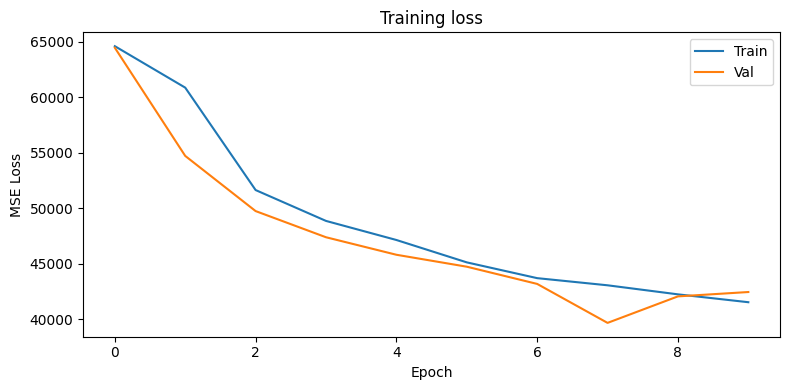

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training loss")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Verify aggression by counting # of f-presses in validation
eval_epoch(model, val_loader, device, -1, check_aggression=True)

Evaluation -1: 100%|██████████| 30/30 [07:15<00:00, 14.51s/it]

Final Play Rate: 63.6


42448.476302083334

In [27]:
import datetime

today = datetime.date.today().strftime("%Y-%m-%d")

ckpt_path = PROJECT_ROOT / "checkpoints"
ckpt_path.mkdir(exist_ok=True)
model_output_name = f"{today}-{cfg.name}.pt"

torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses":         train_losses,
    "val_losses":           val_losses,
    "experiment_config":    cfg.to_dict(),
}, ckpt_path / model_output_name)

print(f"Saved checkpoint: {ckpt_path / model_output_name}")
print(f"Experiment: {cfg.name}  |  Network: {cfg.network_class}  |  Outputs: {NUM_OUTPUTS}")

Saved checkpoint: C:\Users\Py Torch\Documents\GitHub\Sillyness\RL_Resistance_MM\modeling\checkpoints\2026-03-09-deep_q_v1.1.pt
Experiment: deep_q_v1.1  |  Network: DQN_V1.1  |  Outputs: 26
